# Information Theory

https://medium.com/towards-data-science/quantifying-uncertainty-4814b759da5f?sk=v2%2Fbe4cd022-f54e-4dc5-b0cc-14b217a6e5dd

- Byte Latent Transformer

## Self Information

$$h_x = -log_2(p(x))$$

- "surprise" of an element x, occuring based on its probability

- **bits**: binary digit (log base is 2)

- 0% and 100% are both not surprising, $h_x=0$.

- Self-information of indpendent events are additive

## Entropy

- Average amount of information learnable from the distribution of a variable

- uncertainty or average "element of surprise"

$$H_x = \sum\limits_{i=1}^c p_X(x_i)h_{x_i} = - \sum\limits_{i=1}^c p_X(x_i)log_2(p_X(x_i))$$

- $h_X = -log_2((p_X(x))$ : the self-information for each event X

- $p_X(x)$ : the weight to the expectancy of its occurence, 확률 가중평균?

## Code Implementation

### Basic $h_x$

In [ ]:
# implementation

import numpy as np
# pxs = [0.5, 0.5] #50% 대 50%, maximum entropy, result is 1 bit.
pxs = [0.9, 0.1]
# pxs = [14, 14]
# pxs = [0, 1]
entropy = np.sum([-px * np.log2(px) for px in pxs])
print(f"{entropy=} (bits)")

entropy=0.4689955935892812 (bits)


In [ ]:
# internal module
from scipy.stats import entropy
# 아래와 같은 것들도 알아서 처리된다.
# pxs = [14, 14] #normalization applied
# pxs = [0, 1] # 0 handled
entropy(pxs, base=2) # base is 2

1.0

### Entropy of a Bernoulli trial

- max entropy: $p=\frac{1}{2}$ -> H=1 bit, equal potential outcome, max uncertainty

Text(0, 0.5, 'bits')

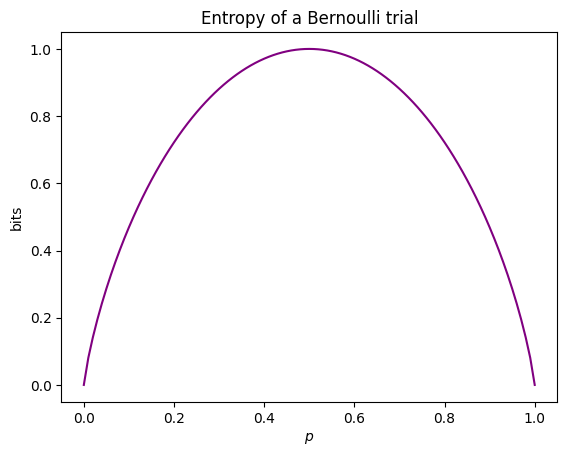

In [ ]:
import numpy as np
from scipy.stats import entropy
import matplotlib.pyplot as plt

# entropy for range 0-1 in intervals of 0.01
entropies = {p_: entropy([p_, 1-p_], base=2) for p_ in np.arange(0, 1.01, 0.01)}

# plotting
plt.plot(list(entropies.keys()), entropies.values(), color='purple')
plt.title('Entropy of a Bernoulli trial')
plt.xlabel(r'$p$')
plt.ylabel('bits')

### Implementation

3 variables

<ipython-input-20-e5e93efeb4bf>:26: RuntimeWarning: divide by zero encountered in log2
  logs = np.log2(p_array) if base == 2 else np.log(p_array)
<ipython-input-20-e5e93efeb4bf>:27: RuntimeWarning: invalid value encountered in multiply
  return -np.sum(p_array * logs, axis=1) / (1 if base == 2 else np.log(base))


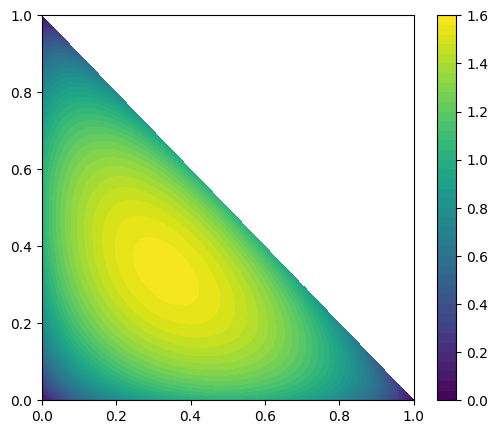

In [ ]:
import numpy as np
from scipy.stats import entropy

dd = 0.001
x_values = np.arange(0, 1 + dd, dd)
y_values = np.arange(0, 1 + dd, dd)
X, Y = np.meshgrid(x_values, y_values)
Z = 1 - X - Y

# Valid region
mask = (Z >= 0)

# Create p array with shape (n_points, 3)
# Flatten X, Y, Z and combine them
p = np.stack([X[mask], Y[mask], Z[mask]], axis=1)  # shape = (valid_points, 3)

# Compute entropy for all rows in p at once:
#     SciPy's entropy() doesn't directly accept a 2D array in "one go".
#     But we can do it manually using the formula:
#     H = -\sum p_i log2(p_i).
import numpy as np

def manual_entropy(p_array, base=2):
    # p_array: shape (n_points, 3)
    # return: shape (n_points,) entropies
    logs = np.log2(p_array) if base == 2 else np.log(p_array)
    return -np.sum(p_array * logs, axis=1) / (1 if base == 2 else np.log(base))

ent = manual_entropy(p)

# Now put those computed values back into the 2D grid
entropy_values = np.full_like(X, np.nan, dtype=float)
entropy_values[mask] = ent

# Then plot as usual
import matplotlib.pyplot as plt
plt.figure(figsize=(6,5))
cs = plt.contourf(X, Y, entropy_values, levels=50)  # e.g. 50 contour levels
plt.colorbar(cs)
plt.show()

### Entropy and Information Trade-Off

- tiles of ascii emojis
- probability $p=\frac{1}{256}$
- entropy(uncertainty): $h = -log_2(p) = 8$ bits

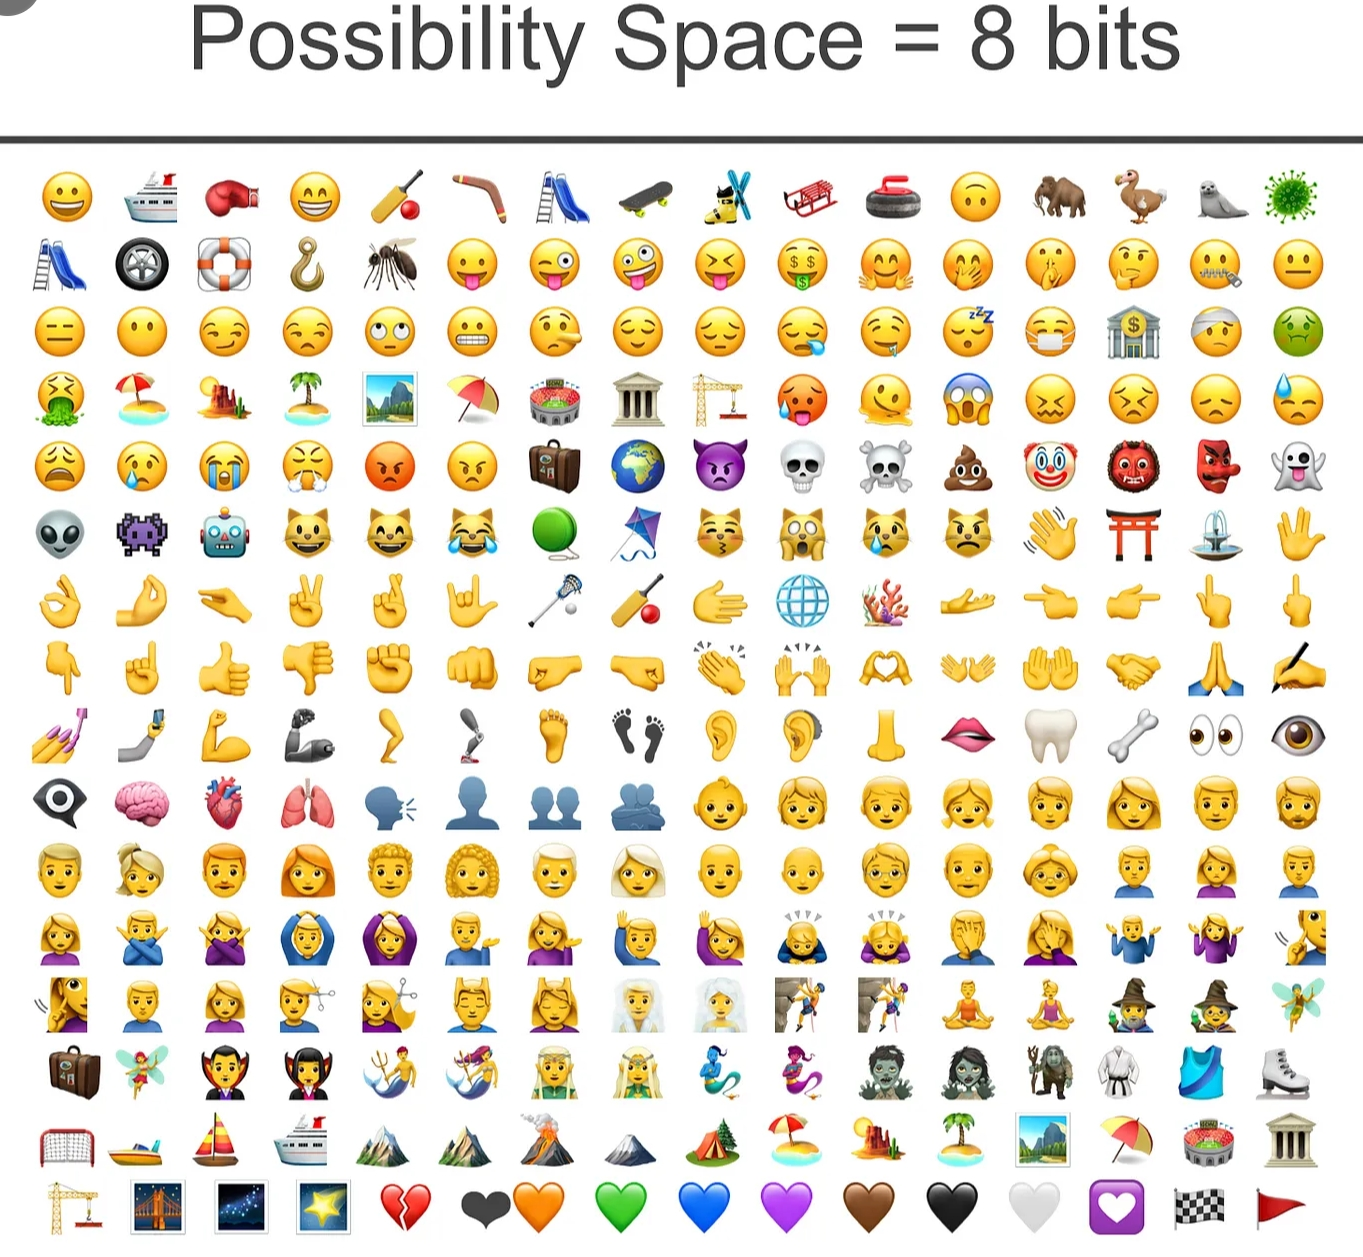

- Halve the space
- possibility set reduced by 2 (p=1/2)
- 'subspace' entropy is $h = -log_2(\frac{1}{128}) = 7$ bits
- Or, $-log_2(\frac{1}{2}) = 1$ bit of "information is gained"

- **"Halving until single element"** where `entropy = 0`.

## Entropy applied models: Decision Trees

- Random Forest and Gradient Boosting Trees etc
- top-down greedy search of splitting to find "pure" cluster.

$$ \text{Childern Impurity} = \frac{n^L}{n}H^L + \frac{n^R}{n}H^R$$

- L: left, R: right side splitting
- $n^i$: size of children node
- $n=n^L+n^R$ parent node size before splitting
- $H^i$: entropy of the child
- **"weighted sum of entropy"**

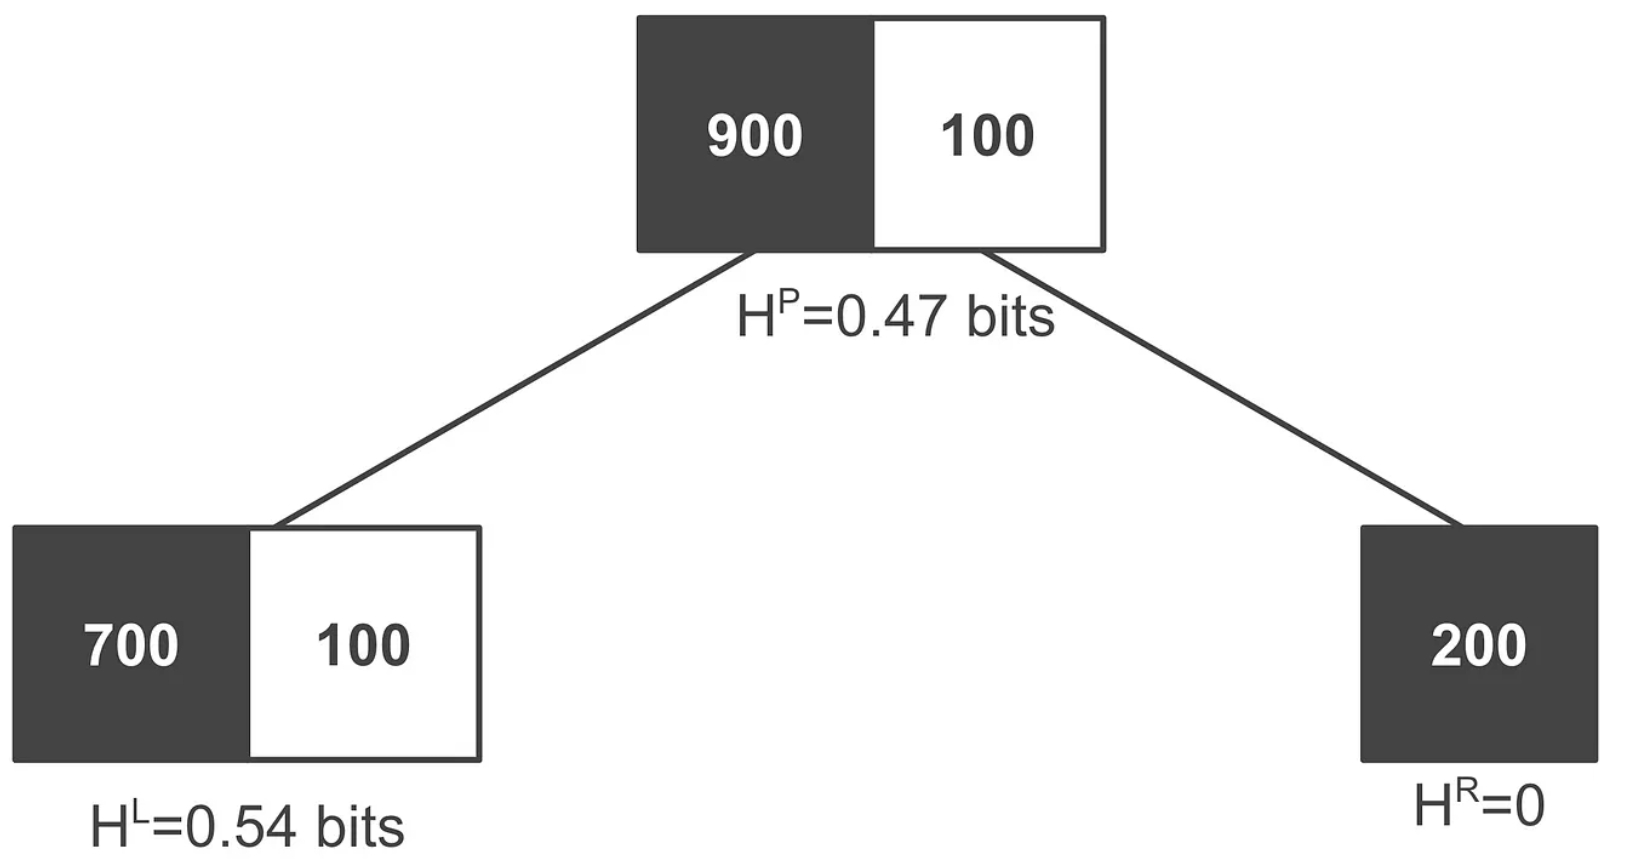

- black is positive
- Children Impurity = 800/1000 * 0.54 + 200/1000 * 0 = 0.43

- Children Average Entropy < Parent's Entropy

- **"gain of information by splitting"** by concavity of entropy function

In [ ]:
from scipy.stats import entropy

def split_impurity_entropy(ps_childL, ps_childR, base=2):
    n_L = sum(ps_childL)
    n_R = sum(ps_childR)
    n = n_L + n_R

    H_childL = entropy(ps_childL, base=base)
    H_childR = entropy(ps_childR, base=base)

    average_impurity = (n_L / n) * H_childL + (n_R / n) * H_childR

    return average_impurity

In [ ]:
# node class frequencies
ps_parent = [700, 300]
ps_childL = [300, 290]
ps_childR = [ps_parent[0] - ps_childL[0], ps_parent[1] - ps_childL[1]]

# node entropies
H_parent = entropy(ps_parent, base=2)
H_childL = entropy(ps_childL, base=2)
H_childR = entropy(ps_childR, base=2)
H_childrenA = split_impurity_entropy(ps_childL, ps_childR)

print(f"parent entropy: {H_parent:0.2f}")
print(f"childL entropy: {H_childL:0.4f}")
print(f"childR entropy:{H_childR: 0.2f}")
print("-" * 20)
print(f"average child impurity: {H_childrenA:0.2f}")

parent entropy: 0.88
childL entropy: 0.9998
childR entropy: 0.17
--------------------
average child impurity: 0.66


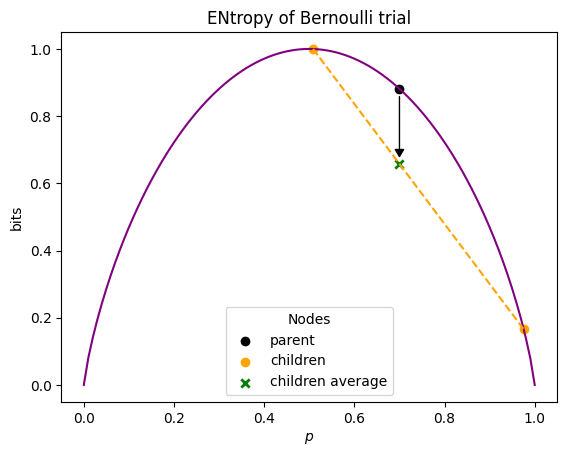

In [ ]:
# range of entropies
entropies = {p_: entropy([p_, 1-p_], base=2) for p_ in np.arange(0, 1.01, 0.01)}

plt.plot(list(entropies.keys()), entropies.values(), color='purple')
plt.title('ENtropy of Bernoulli trial')
plt.xlabel('$p$')
plt.ylabel('bits')

# node frequencies
p_parent = ps_parent[0] / sum(ps_parent)
p_childL = ps_childL[0] / sum(ps_childL)
p_childR = ps_childR[0] / sum(ps_childR)

plt.scatter([p_parent,], [H_parent], color='black', label='parent')
plt.scatter([p_childL, p_childR], [H_childL, H_childR], color='orange', label='children')
plt.plot([p_childL, p_childR], [H_childL, H_childR], color='orange', linestyle='--')
plt.scatter([p_parent], [H_childrenA], color='green', label='children average', marker="x", linewidth=2)

plt.annotate('', xy=(p_parent, H_childrenA + 0.01), xytext=(p_parent, H_parent - 0.015), arrowprops=dict(facecolor='black', linewidth=1, arrowstyle="-|>, head_width=0.3, head_length=0.5"))
plt.legend(title="Nodes")

### Full-Degeneracy of DNA sequencing

- nucleotides A,C,T, and G with equal probability
- Ideal full-degeneracy $-log_2(1/4)=2$ bits = "1 fit"

### Monty Hall Problem

- 3 doors, 1 car and 2 goats.
- 1 goat is revealed
- `[1/3, 1/3, 1/3]` -> `[1/3, 2/3, 0]`
- -log_2((1/3)) = 1.58
- `[1.58, 1.58, 1.58]` -> `[1.58, 0.58, 0]`

- $H_\text{initial} = -log_2 N$

- $H_\text{final} = -\frac{1}{N}log_2(\frac{1}{N}) - \frac{N-1}{N}log_2(\frac{N-1}{N})$


정보 이득(Information Gain) =

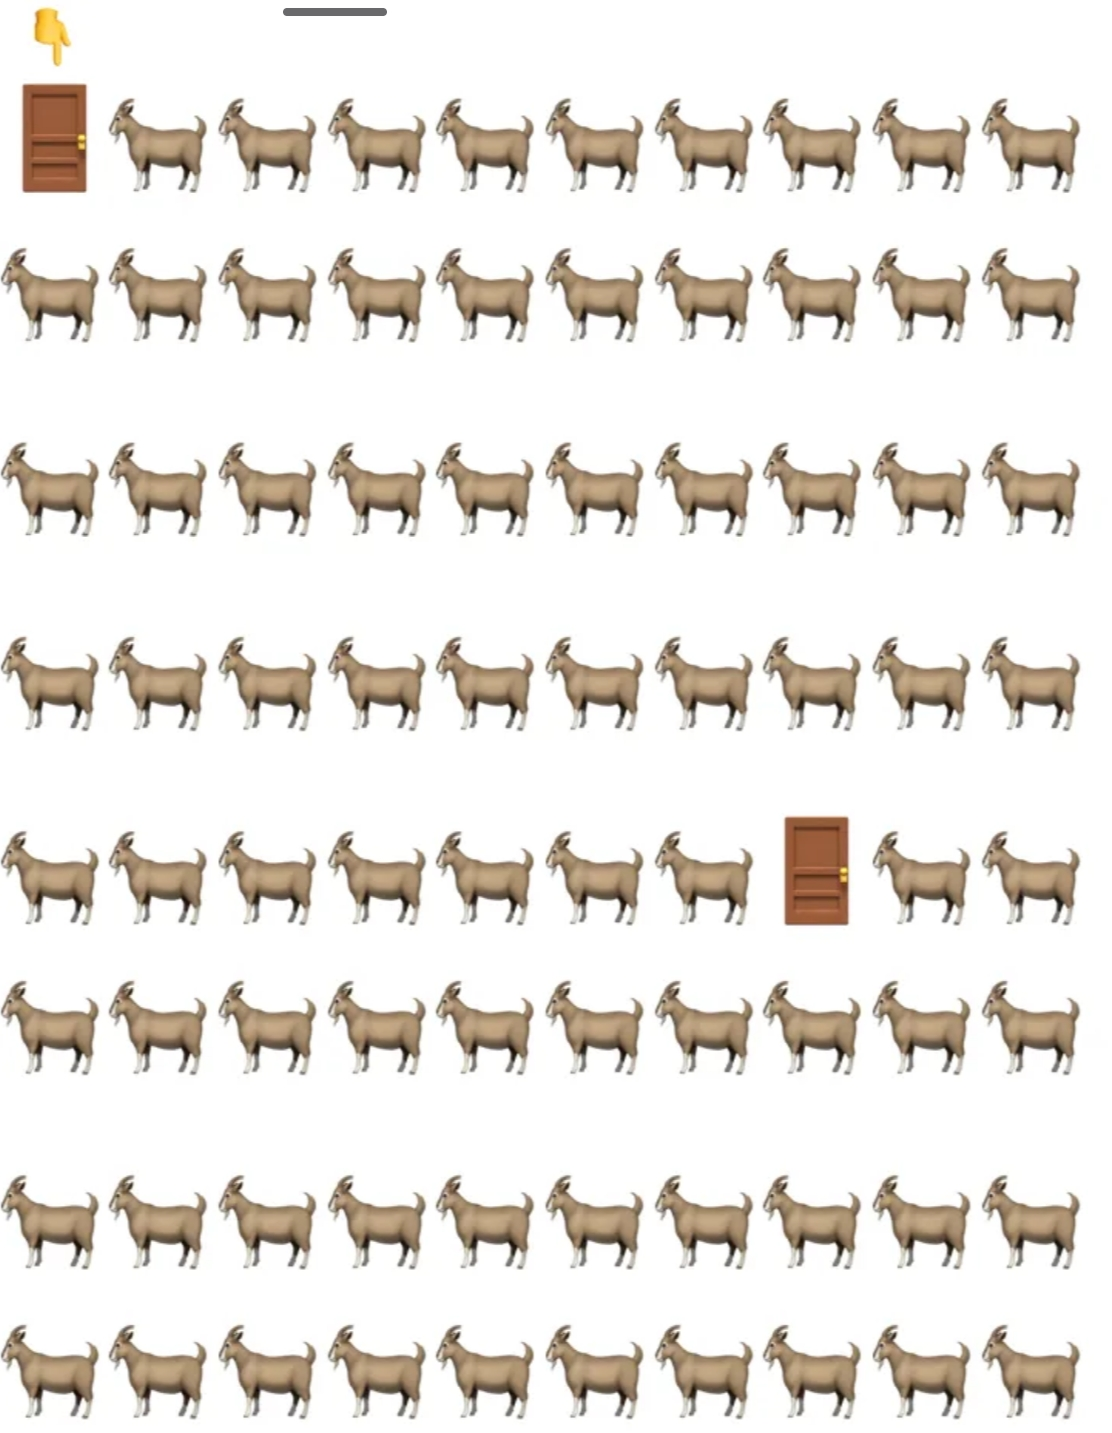

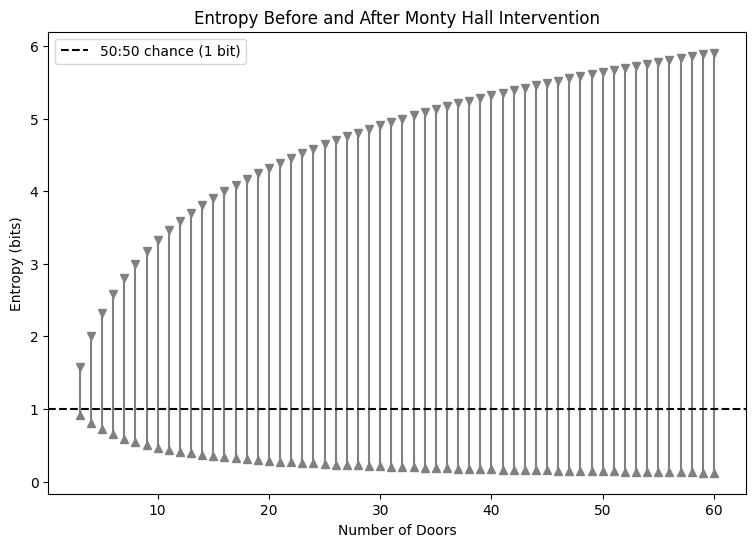

In [ ]:
import math
import matplotlib.pyplot as plt

def monty_hall_entropy_initial(N):
    """
    초기 엔트로피: 문 N개 중 1개가 당첨일 때 불확실성
    H = log2(N)
    """
    return math.log2(N)

def monty_hall_entropy_final(N):
    """
    사회자 개입 후 엔트로피:
    - 플레이어가 처음 고른 문이 차일 확률: 1/N
    - 나머지 한 문(수많은 염소를 열고 남긴 문)이 차일 확률: (N-1)/N

    H = -p*log2(p) - (1-p)*log2(1-p)
      = -(1/N)*log2(1/N) - ((N-1)/N)*log2((N-1)/N)
    """
    p = 1.0 / N
    return -(p * math.log2(p) + (1 - p) * math.log2(1 - p))

def plot_monty_hall_entropy(max_doors=60):
    Ns = range(3, max_doors+1)  # 3문 이상부터 예시
    initial_entropies = [monty_hall_entropy_initial(N) for N in Ns]
    final_entropies   = [monty_hall_entropy_final(N)   for N in Ns]

    # 그래프 그리기
    plt.figure(figsize=(9,6))

    for i, N in enumerate(Ns):
        plt.plot([N, N], [final_entropies[i], initial_entropies[i]],
                 color='gray')
        # 화살표 꼬리 (initial)
        plt.plot(N, initial_entropies[i], 'v', color='gray')
        # 화살표 머리 (final)
        plt.plot(N, final_entropies[i], '^', color='gray')

    # 50:50 확률(엔트로피 = 1비트) 보조선
    plt.axhline(y=1.0, color='black', linestyle='--',
                label='50:50 chance (1 bit)')

    plt.xlabel('Number of Doors')
    plt.ylabel('Entropy (bits)')
    plt.title('Entropy Before and After Monty Hall Intervention')
    plt.legend()
    plt.show()

# 실행
plot_monty_hall_entropy(60)